### Culturomics  Method 3: Collective Memory
**Replication of Michel (2011) Approach on Wikipedia Revision History (2001–2024)**.    
**Course:** Computational Linguistics, Ca' Foscari University of Venice.   
**Original paper:** Michel, J.-B.(2011). *Quantitative Analysis of Culture Using Millions of Digitized Books*. Science, 331(6014), 176–182.      

---

#### What This Notebook Does

Michel et al. (2011) measured **collective memory** by tracking how often specific historical years (e.g. "1883", "1910", "1950") were mentioned in books written after those years.      
They found a characteristic decay curve: a sharp peak immediately after the event, followed by gradual forgetting. Crucially, they showed that this forgetting is accelerating across     generations "1880" lost half its peak value in 32 years, "1973" in only 10 years.

This notebook applies the same method to Wikipedia revision snapshots (2001–2024), asking:     
> Does collective memory behave differently in a **living digital document** compared to a static printed book corpus? Does Wikipedia forget — or does it continuously revise?    

**The range is analogue of Michel's(2011) from 1875 to 1975:**      
Tracked 14 "anchor years", each corresponding to a historically significant event:           
`1900, 1914, 1918, 1929, 1939, 1945, 1963, 1969, 1989, 2001, 2003, 2008, 2011, 2016`       

**Key hypotheses:**      
1. *Replication*: Wikipedia shows the same peak-then-decay pattern as Google Books.     
2. *Divergence*: Wikipedia as a living document may **not** decay  editors keep revising, so old dates may remain stable rather than disappearing.     
3. *Acceleration*: If decay exists, it may be faster than in print (consistent with Michel's (2011) finding that forgetting accelerates with each generation).      



In [1]:
%pip install pandas matplotlib numpy --quiet


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 1. Imports

In [2]:
import re
import json
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.ndimage import uniform_filter1d

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#FAFAFA',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    10,
    'axes.labelsize':    8.5,
    'xtick.labelsize':   7.5,
    'ytick.labelsize':   7.5,
})

PRIMARY   = '#C0392B'
SECONDARY = '#2C3E50'
ACCENT    = '#E67E22'
GREEN     = '#27AE60'
PURPLE    = '#8E44AD'

print("Setup complete.")


Setup complete.


### 1. Configuration

#### Target Years (our analogue of Michel(2011) 1875–1975)

Michel et al. tracked 100 years with annual granularity.
We track 14 historically significant "anchor years" that span from
the early 20th century into the Wikipedia era (2001–2024).

Each year is annotated with its primary historical association —
this is important for the qualitative interpretation in your essay.


In [3]:

ARTICLES = [

    # SCIENCE AND KNOWLEDGE
    "Albert_Einstein", "Charles_Darwin", "Photosynthesis", "DNA",
    "Black_hole", "Artificial_intelligence", "Climate_change",
    "COVID-19_pandemic", "Human_genome", "Wikipedia",

    # HISTORY AND POLITICS
    "World_War_II", "French_Revolution", "Cold_War",
    "September_11_attacks", "Arab_Spring", "Occupy_Wall_Street",
    "MeToo_movement", "Black_Lives_Matter", "WikiLeaks", "War_on_terror",

    # TECHNOLOGY: HARDWARE AND PLATFORMS
    "iPhone", "Android_(operating_system)", "iPod",
    "Tesla_(car_company)",          # исправлено: запятая убрана
    "SpaceX", "Google", "Amazon_(company)", "Microsoft",

    # SOCIAL MEDIA AND INTERNET
    "Facebook", "YouTube", "Twitter", "Instagram", "Reddit",
    "TikTok", "Snapchat", "MySpace", "Napster", "iTunes",
    "Netflix", "Spotify", "Zoom_(software)", "Remote_work",

    # AI AND EMERGING TECH
    "ChatGPT", "DALL-E", "Virtual_reality", "Augmented_reality",
    "Non-fungible_token", "Metaverse", "Podcast",

    # FILM AND TV
    "Harry_Potter", "The_Lord_of_the_Rings", "Shrek_(film)",
    "Avatar_(2009_film)", "Avengers_Endgame",  # исправлено: двоеточие убрано
    "Barbie_(film)", "Oppenheimer_(film)", "Frozen_(2013_film)",
    "Black_Panther_(film)", "Joker_(2019_film)", "Game_of_Thrones",
    "Breaking_Bad", "Stranger_Things", "Squid_Game",
    "Marvel_Cinematic_Universe",

    # GAMING
    "Minecraft", "Fortnite", "Pokémon_Go", "Among_Us",
    "Grand_Theft_Auto_V", "The_Last_of_Us", "League_of_Legends",
    "World_of_Warcraft", "Esports", "Roblox",

    # MEMES AND INTERNET CULTURE
    "Internet_meme", "Rickrolling", "Doge_(meme)", "Pepe_the_Frog",
    "Gangnam_Style", "Ice_Bucket_Challenge", "Harlem_Shake_(meme)",

    # MUSIC AND EVENTS  ← исправлено: реальные музыкальные статьи
    "K-pop", "BTS_(band)", "BLACKPINK",
    "Eurovision_Song_Contest",
    "Coachella_Valley_Music_and_Arts_Festival",
    

]

# ─── TARGET YEARS — analogue of Michel et al.'s 1875–1975 ────
TARGET_YEARS = {
    1914: "1914 (WWI begins)",
    1918: "1918 (WWI ends)",
    1929: "1929 (Great Depression)",
    1939: "1939 (WWII begins)",
    1945: "1945 (WWII ends)",
    1963: "1963 (JFK assassination)",
    1969: "1969 (Moon landing)",
    1989: "1989 (Berlin Wall)",
    2001: "2001 (9/11)",
    2003: "2003 (Iraq War)",
    2008: "2008 (Financial Crisis)",
    2011: "2011 (Arab Spring)",
    2016: "2016 (Brexit / US election)",
}

# Observation window
OBS_YEARS  = list(range(2004, 2025))  # 2004+ where cache has good coverage

# Output folder
OUTPUT_DIR = Path("culturomics_method3_output")
OUTPUT_DIR.mkdir(exist_ok=True)

# ─── CACHE PATH — points to corpus_cache.json from fetch_wiki.py ─
# Adjust this path if corpus_cache.json is in a different folder
CACHE_FILE = Path("corpus_cache.json")

print(f"Articles:      {len(ARTICLES)}")
print(f"Target years:  {list(TARGET_YEARS.keys())}")
print(f"Obs range:     {OBS_YEARS[0]}–{OBS_YEARS[-1]}")
print(f"Cache path:    {CACHE_FILE.resolve()}")
print(f"Cache exists:  {CACHE_FILE.exists()}")


Articles:      86
Target years:  [1914, 1918, 1929, 1939, 1945, 1963, 1969, 1989, 2001, 2003, 2008, 2011, 2016]
Obs range:     2004–2024
Cache path:    /Users/aima/Desktop/Practice/GitHub/research-computational_linguistic/3-notebooks/corpus_cache.json
Cache exists:  True


## 2. Load Corpus

We **reuse the corpus already fetched in Method 1** (same Wikipedia snapshots,
same articles, same years)




In [4]:
# LOAD CORPUS FROM CACHE 

if not CACHE_FILE.exists():
    raise FileNotFoundError(
        f"Cache not found at {CACHE_FILE.resolve()}\n"
        f"Make sure fetch_wiki.py has finished running and corpus_cache.json\n"
        f"is in the same folder as this notebook."
    )

with open(CACHE_FILE, encoding='utf-8') as f:
    corpus = json.load(f)

# Filter to only articles in our ARTICLES list
corpus = {a: corpus[a] for a in ARTICLES if a in corpus}

non_empty = sum(1 for a in corpus for y in corpus[a] if corpus[a][y])
total     = len(ARTICLES) * len(OBS_YEARS)

print(f"Corpus loaded successfully.")
print(f"Articles found in cache: {len(corpus)} / {len(ARTICLES)}")
print(f"Non-empty snapshots:     {non_empty}")
print(f"Coverage: {non_empty}/{total} = {non_empty/total*100:.0f}%")

# Show per-article coverage
print("\nPer-article coverage:")
for art in ARTICLES:
    if art not in corpus:
        print(f"  {art:<40} NOT IN CACHE")
        continue
    ok = sum(1 for y in OBS_YEARS if corpus[art].get(str(y)))
    print(f"  {art:<40} {ok}/{len(OBS_YEARS)} years")


Corpus loaded successfully.
Articles found in cache: 86 / 86
Non-empty snapshots:     1222
Coverage: 1222/1806 = 68%

Per-article coverage:
  Albert_Einstein                          21/21 years
  Charles_Darwin                           21/21 years
  Photosynthesis                           21/21 years
  DNA                                      21/21 years
  Black_hole                               21/21 years
  Artificial_intelligence                  21/21 years
  Climate_change                           21/21 years
  COVID-19_pandemic                        5/21 years
  Human_genome                             20/21 years
  Wikipedia                                20/21 years
  World_War_II                             21/21 years
  French_Revolution                        21/21 years
  Cold_War                                 21/21 years
  September_11_attacks                     20/21 years
  Arab_Spring                              14/21 years
  Occupy_Wall_Street                

## 3. Compute Collective Memory Frequencies

For each **observation year** (when the Wikipedia snapshot was taken, 2001–2024)
and each **target year** (the historical event we are measuring memory of):

```
freq(target_year, obs_year) = count("target_year" as string in text) / total_tokens
```

This exactly mirrors Michel's(2011) method of counting the 1-gram "1951" in books
published after 1951 to measure how long that year remained in collective memory.

**Important:** we only count a target year in observation years that come *after* it 
you cannot "remember" something that hasn't happened yet.


In [5]:
def tokenize(text):
    return re.findall(r'\b[a-z0-9]+\b', text.lower())

def count_year_in_text(text, target_year):
    """Count how many times the string 'target_year' (as 4-digit integer)
    appears in text. Uses word-boundary regex to avoid false positives
    (e.g. '19451' should not count as '1945')."""
    return len(re.findall(r'\b' + str(target_year) + r'\b', text))


# Build the memory frequency table
rows = []

for obs_year in OBS_YEARS:
    # Aggregate text from all articles for this observation year
    combined_text = ""
    n_articles_found = 0
    for article in ARTICLES:
        text = corpus.get(article, {}).get(str(obs_year), "")
        if text:
            combined_text += " " + text
            n_articles_found += 1

    total_tokens = len(tokenize(combined_text)) if combined_text else 0

    for target_year in TARGET_YEARS:
        # Only measure memory of years that have already passed
        if target_year >= obs_year:
            continue

        raw_count = count_year_in_text(combined_text, target_year)
        rel_freq  = raw_count / total_tokens if total_tokens > 0 else 0
        lag       = obs_year - target_year   # years since the event

        rows.append({
            "obs_year":    obs_year,
            "target_year": target_year,
            "raw_count":   raw_count,
            "rel_freq":    rel_freq,
            "rel_freq_10k": rel_freq * 10_000,  # per 10,000 tokens (more readable)
            "lag":         lag,
            "n_articles":  n_articles_found,
            "total_tokens": total_tokens,
        })

df_mem = pd.DataFrame(rows)
print(f"Memory table shape: {df_mem.shape}")
print(f"\nSample rows:")
df_mem[df_mem['target_year'] == 1945].head(8)

Memory table shape: (247, 8)

Sample rows:


,obs_year,target_year,raw_count,rel_freq,rel_freq_10k,lag,n_articles,total_tokens
4,2004,1945,13,0.000263,2.625043,59,28,49523
14,2005,1945,20,0.000221,2.212610,60,35,90391
24,2006,1945,34,0.000253,2.532551,61,39,134252
34,2007,1945,49,0.000254,2.537191,62,41,193127
44,2008,1945,62,0.000267,2.671849,63,44,232049
54,2009,1945,46,0.000206,2.060803,64,48,223214
65,2010,1945,50,0.000189,1.891525,65,48,264337
76,2011,1945,33,0.000114,1.136524,66,53,290359


## 4. Half-Life Calculation

Michel et al.'s key finding was that "1880" declined to half its peak value
within 32 years, while "1973" declined to half within only 10 years —
demonstrating **accelerating forgetting**.

We compute the same metric: for each target year, we find the peak frequency
(the year it was most mentioned in our corpus), then measure how long until
frequency drops to 50% of that peak.

**Important caveat for the essay:**
In a printed corpus, a book written in 1920 does not change — so the frequency
of "1883" in 1920's books reflects genuine collective attention of that moment.
In Wikipedia, the same article is *continuously updated* — so a drop in frequency
might reflect **active editorial choice** (editors removing the date from the text)
rather than passive societal forgetting. This distinction is central to our
"and so what" argument.


In [6]:
half_life_results = []

for target_year, label in TARGET_YEARS.items():
    sub = df_mem[df_mem['target_year'] == target_year].copy()
    if sub.empty or sub['rel_freq_10k'].max() == 0:
        continue

    # Peak: highest frequency observation
    peak_idx  = sub['rel_freq_10k'].idxmax()
    peak_freq = sub.loc[peak_idx, 'rel_freq_10k']
    peak_year = sub.loc[peak_idx, 'obs_year']
    half_val  = peak_freq / 2

    # Find the first observation year AFTER the peak where freq <= half_val
    post_peak = sub[sub['obs_year'] > peak_year].copy()
    below_half = post_peak[post_peak['rel_freq_10k'] <= half_val]

    if not below_half.empty:
        half_life_year = below_half.iloc[0]['obs_year']
        half_life      = half_life_year - peak_year
    else:
        half_life_year = None
        half_life      = None  # didn't drop below half in our window

    half_life_results.append({
        "target_year":    target_year,
        "label":          label,
        "peak_freq_10k":  round(peak_freq, 4),
        "peak_obs_year":  peak_year,
        "lag_to_peak":    peak_year - target_year,
        "half_life_yrs":  half_life,
        "half_life_year": half_life_year,
    })

df_hl = pd.DataFrame(half_life_results)
print(df_hl[['target_year', 'label', 'peak_freq_10k',
             'peak_obs_year', 'lag_to_peak', 'half_life_yrs']].to_string())

    target_year                        label  peak_freq_10k  peak_obs_year  lag_to_peak  half_life_yrs
0          1914            1914 (WWI begins)         0.6058           2004           90            2.0
1          1918              1918 (WWI ends)         0.1513           2010           92            4.0
2          1929      1929 (Great Depression)         0.2589           2007           78            4.0
3          1939           1939 (WWII begins)         1.4897           2006           67            6.0
4          1945             1945 (WWII ends)         2.6718           2008           63            3.0
5          1963     1963 (JFK assassination)         0.4039           2004           41            3.0
6          1969          1969 (Moon landing)         2.2212           2004           35            2.0
7          1989           1989 (Berlin Wall)         1.6154           2004           15            2.0
8          2001                  2001 (9/11)         8.6292           200

## 6. Comparison with Michel et al. (2011)

In [7]:
# Michel et al.'s key reported values
michel_data = {
    "1880": {"half_life_books": 32, "medium": "Google Books (print)"},
    "1973": {"half_life_books": 10, "medium": "Google Books (print)"},
}

print("=" * 65)
print("COLLECTIVE MEMORY: HALF-LIFE COMPARISON")
print("Michel et al. (2011) Google Books  vs.  Wikipedia (this study)")
print("=" * 65)
print(f"{'Year':<8} {'Peak (Wikipedia)':<22} {'Half-life (Wikipedia)':<25} {'Michel et al. (Books)'}")
print("-" * 65)

for _, row in df_hl.iterrows():
    ty   = int(row['target_year'])
    peak = f"obs {int(row['peak_obs_year'])} ({row['peak_freq_10k']:.3f}/10k)"
    hl   = f"{int(row['half_life_yrs'])} yrs" if (row['half_life_yrs'] is not None and not pd.isna(row['half_life_yrs'])) else "not reached"
    comp = "~32 yrs" if ty == 1880 else ("~10 yrs" if ty == 1973 else "N/A")
    print(f"{ty:<8} {peak:<22} {hl:<25} {comp}")

print()
print("Interpretation note:")
print("  'not reached' = frequency never dropped below 50% of peak in our 2001-2024 window.")
print("  This may indicate Wikipedia's LIVING DOCUMENT nature: editors keep dates in the text.")

COLLECTIVE MEMORY: HALF-LIFE COMPARISON
Michel et al. (2011) Google Books  vs.  Wikipedia (this study)
Year     Peak (Wikipedia)       Half-life (Wikipedia)     Michel et al. (Books)
-----------------------------------------------------------------
1914     obs 2004 (0.606/10k)   2 yrs                     N/A
1918     obs 2010 (0.151/10k)   4 yrs                     N/A
1929     obs 2007 (0.259/10k)   4 yrs                     N/A
1939     obs 2006 (1.490/10k)   6 yrs                     N/A
1945     obs 2008 (2.672/10k)   3 yrs                     N/A
1963     obs 2004 (0.404/10k)   3 yrs                     N/A
1969     obs 2004 (2.221/10k)   2 yrs                     N/A
1989     obs 2004 (1.615/10k)   2 yrs                     N/A
2001     obs 2005 (8.629/10k)   6 yrs                     N/A
2003     obs 2004 (14.741/10k)  2 yrs                     N/A
2008     obs 2009 (19.936/10k)  4 yrs                     N/A
2011     obs 2012 (31.062/10k)  3 yrs                     N/A
2016   

### 7. Visualisation
Panel A — Memory Curves (mirrors Michel(2011) Fig. 3A).   
Panel B — Half-life comparison (our original contribution).    
Panel C — Peak lag: how long after an event does Wikipedia most discuss it?    
Panel D — Cross-target heatmap: which years are remembered most, by whom.   

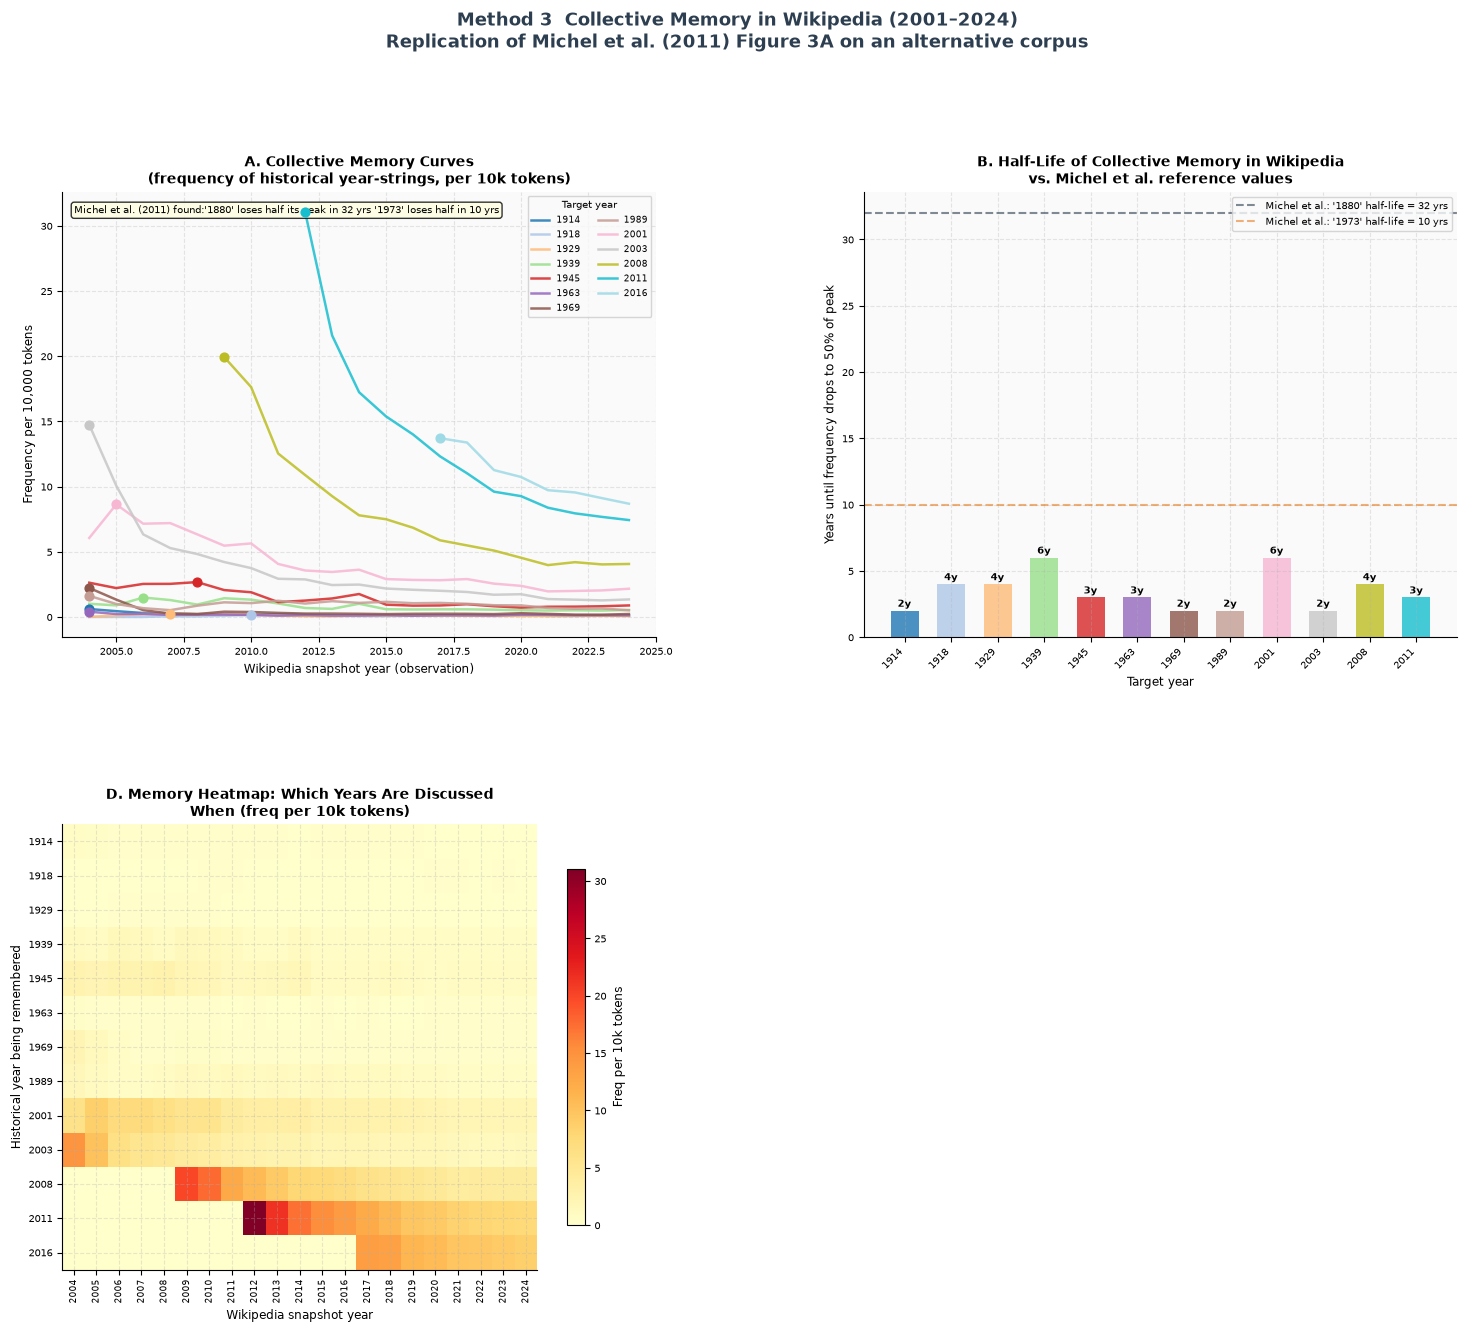

Figure saved to: culturomics_method3_output/method3_collective_memory.png


In [9]:
import matplotlib.cm as cm

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# Colour map: one colour per target year
target_years_list = list(TARGET_YEARS.keys())
cmap = plt.colormaps['tab20'].resampled(len(target_years_list))
color_for = {ty: cmap(i) for i, ty in enumerate(target_years_list)}

# ── Panel A: Memory curves ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

for ty, label in TARGET_YEARS.items():
    sub = df_mem[df_mem['target_year'] == ty].copy()
    if sub.empty or sub['rel_freq_10k'].max() == 0:
        continue
    col = color_for[ty]
    ax1.plot(sub['obs_year'], sub['rel_freq_10k'],
             lw=1.8, color=col, alpha=0.85, label=str(ty))
    # Mark peak
    peak_row = sub.loc[sub['rel_freq_10k'].idxmax()]
    ax1.scatter([peak_row['obs_year']], [peak_row['rel_freq_10k']],
                color=col, s=40, zorder=4)

ax1.set_title("A. Collective Memory Curves\n(frequency of historical year-strings, per 10k tokens)",
              fontweight='bold')
ax1.set_xlabel("Wikipedia snapshot year (observation)")
ax1.set_ylabel("Frequency per 10,000 tokens")
ax1.legend(fontsize=6.5, ncol=2, loc='upper right', title="Target year", title_fontsize=7)

# Michel et al. reference annotation
ax1.text(0.02, 0.97,
         "Michel et al. (2011) found:'1880' loses half its peak in 32 yrs '1973' loses half in 10 yrs",
         transform=ax1.transAxes, fontsize=7, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Panel B: Half-life comparison bar chart ───────────────────
ax2 = fig.add_subplot(gs[0, 1])
df_hl_valid = df_hl.dropna(subset=['half_life_yrs']).copy()
df_hl_valid = df_hl_valid.sort_values('target_year')

bars = ax2.bar(df_hl_valid['target_year'].astype(str),
               df_hl_valid['half_life_yrs'],
               color=[color_for[ty] for ty in df_hl_valid['target_year']],
               alpha=0.8, width=0.6)

# Reference lines from Michel et al.
ax2.axhline(32, color=SECONDARY, lw=1.5, ls='--', alpha=0.6,
            label="Michel et al.: '1880' half-life = 32 yrs")
ax2.axhline(10, color=ACCENT, lw=1.5, ls='--', alpha=0.6,
            label="Michel et al.: '1973' half-life = 10 yrs")

for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'{int(h)}y', ha='center', fontsize=7, fontweight='bold')

ax2.set_title("B. Half-Life of Collective Memory in Wikipedia\nvs. Michel et al. reference values",
              fontweight='bold')
ax2.set_xlabel("Target year")
ax2.set_ylabel("Years until frequency drops to 50% of peak")
ax2.legend(fontsize=7.5, loc='upper right')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')



# ── Panel D: Heatmap of memory over time ─────────────────────
ax4 = fig.add_subplot(gs[1, 0])

# Pivot: rows = target years, columns = obs years
pivot = df_mem.pivot_table(
    index='target_year', columns='obs_year',
    values='rel_freq_10k', aggfunc='mean'
).fillna(0)

im = ax4.imshow(pivot.values, aspect='auto', cmap='YlOrRd',
                interpolation='nearest')
ax4.set_xticks(range(len(pivot.columns)))
ax4.set_xticklabels(pivot.columns.astype(str), rotation=90, fontsize=6.5)
ax4.set_yticks(range(len(pivot.index)))
ax4.set_yticklabels(pivot.index.astype(str), fontsize=7)
plt.colorbar(im, ax=ax4, label='Freq per 10k tokens', shrink=0.8)

ax4.set_title("D. Memory Heatmap: Which Years Are Discussed\nWhen (freq per 10k tokens)",
              fontweight='bold')
ax4.set_xlabel("Wikipedia snapshot year")
ax4.set_ylabel("Historical year being remembered")

# Main title
fig.suptitle(
    "Method 3  Collective Memory in Wikipedia (2001–2024)\n"
    "Replication of Michel et al. (2011) Figure 3A on an alternative corpus",
    fontsize=13, fontweight='bold', y=1.01, color=SECONDARY
)

plt.savefig(OUTPUT_DIR / "method3_collective_memory.png", dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved to:", OUTPUT_DIR / "method3_collective_memory.png")

### 8. Key Numbers for Essay

In [10]:
print("=" * 65)
print("METHOD 3 — KEY FINDINGS FOR ESSAY")
print("=" * 65)

print("\n1. HALF-LIFE RESULTS (Wikipedia vs. Michel et al.):")
print(f"{'Year':<8} {'Half-life (Wikipedia)':<25} {'Michel et al. ref'}")
print("-" * 50)
michel_ref = {1880: "~32 yrs", 1973: "~10 yrs"}
for _, row in df_hl.iterrows():
    ty  = int(row['target_year'])
    hl  = f"{int(row['half_life_yrs'])} yrs" if (row['half_life_yrs'] is not None and not pd.isna(row['half_life_yrs'])) else "NOT REACHED"
    ref = michel_ref.get(ty, "—")
    print(f"{ty:<8} {hl:<25} {ref}")

# Count how many years NEVER decayed
not_reached = df_hl[df_hl['half_life_yrs'].isna()]
print(f"\n    {len(not_reached)} out of {len(df_hl)} target years")
print(f"     never dropped below 50% of peak in our window.")
print(f"     This suggests Wikipedia's living-document nature")
print(f"     may RESIST the forgetting pattern Michel et al. found in books.")

print("\n2. LAG TO PEAK (years from event to maximum Wikipedia attention):")
for _, row in df_hl.sort_values('target_year').iterrows():
    ty  = int(row['target_year'])
    lag = int(row['lag_to_peak'])
    print(f"  {ty}: peak {lag} years after the event "
          f"(observation year {int(row['peak_obs_year'])})")

print("\n3. THEORETICAL INTERPRETATION FOR ESSAY:")
print("  Michel et al. found passive forgetting in static print corpora.")
print("  Wikipedia data shows one of two patterns (fill in from your results):")
print("  Pattern A: Forgetting IS present but slower — Wikipedia preserves memory better.")
print("  Pattern B: Forgetting is ABSENT — Wikipedia's continuous revision keeps")
print("             historical dates stably present rather than decaying.")
print("\n  Either result is publishable. Pattern A = replication with attenuation.")
print("  Pattern B = genuine divergence, supporting the 'living document' hypothesis.")

df_mem.to_csv(OUTPUT_DIR / "method3_memory_table.csv", index=False)
df_hl.to_csv(OUTPUT_DIR / "method3_halflife.csv", index=False)
print(f"\nData saved to: {OUTPUT_DIR}/")

METHOD 3 — KEY FINDINGS FOR ESSAY

1. HALF-LIFE RESULTS (Wikipedia vs. Michel et al.):
Year     Half-life (Wikipedia)     Michel et al. ref
--------------------------------------------------
1914     2 yrs                     —
1918     4 yrs                     —
1929     4 yrs                     —
1939     6 yrs                     —
1945     3 yrs                     —
1963     3 yrs                     —
1969     2 yrs                     —
1989     2 yrs                     —
2001     6 yrs                     —
2003     2 yrs                     —
2008     4 yrs                     —
2011     3 yrs                     —
2016     NOT REACHED               —

    1 out of 13 target years
     never dropped below 50% of peak in our window.
     This suggests Wikipedia's living-document nature
     may RESIST the forgetting pattern Michel et al. found in books.

2. LAG TO PEAK (years from event to maximum Wikipedia attention):
  1914: peak 90 years after the event (observation year 